# Clustering

**Solución:** https://colab.research.google.com/drive/1ccFKhL9MGeIsgKIP8oNySU1aKYiJ_11j?usp=sharing

**Challenge:** https://colab.research.google.com/drive/1outX-txjrv_AnMeY_uda9DIjRiSRMPol?usp=sharing

"If intelligence was a cake, unsupervised learning would be the cake, supervised learning would be the icing on the cake, and reinforcement learning would be the cherry on the cake" - Yann LeCun

Análisis de Agrupamientos: Proceso de particionamiento de un conjunto de datos (u observaciones) en subconjuntos. Cada subconjunto es un grupo o cluster.

* Los datos en un mismo cluster deben ser similares entre sí.
* Los datos de diferentes clusters deben ser diferentes entre sí.

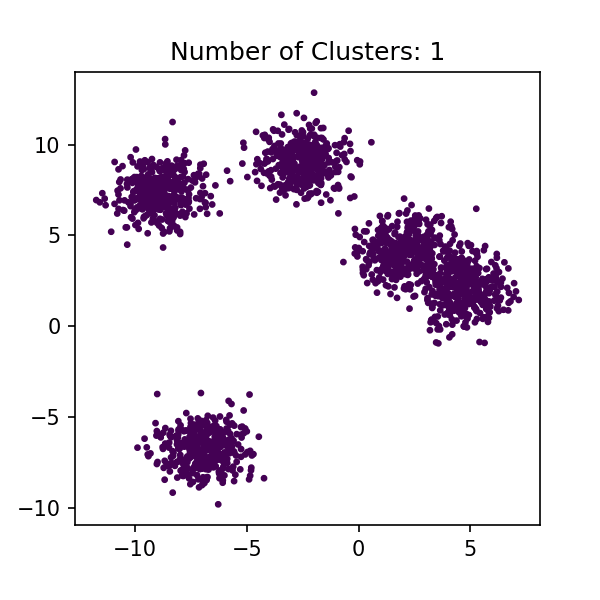

## K-Means

* Método que permite crear __clusters__ a partir de __datos numéricos__. El input del sistema son las mediciones numéricas de interés y los outputs son:
    * los centroides de los __clusters__ resultantes
    * la asignación de cada dato a un __cluster__ determinado.

* El __centroide__ es el punto que se encuentra en el centro de un __cluster__, (es la media de las coordenadas de todos los puntos de ese __cluster__).

* El número de centroides `k` es definido según convenga, para definir la distancia entre puntos y entre centroides se suele utilizar la distancia euclídea.

* La __inercia__ del modelo es la métrica de rendimiento usada para saber donde colocar mejor los centroides, la inercia del modelo es la
distancia media cuadrática entre cada observación y su centroide más cercano.

La Inercia o __Within sum of squares__ se obtiene:

$WSS = \sum_{i = 1}^{K}\sum_{j = 1}^{n_i}{\mid x_{ij} - c_i\mid}^2$

donde:

- $K$, es el número de centroides
- $n_i$, es el número de elementos que pertenecen al centroide $i$
- $c_i$, centroide del cluster $i$
- $x_{ij}$, elemento $j$ del cluster $i$

### Implementación en Scikit-learn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn import datasets
from pprint import pprint

In [ ]:
iris_dat = datasets.load_iris()

iris = (pd.DataFrame(iris_dat.data)
       .rename(columns={0:'sepal_length', 1:'sepal_width', 2:'petal_length', 3:'petal_width'})
       .assign(species=iris_dat.target))

iris.head(20)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


#### Inspección visual (ternary plot)

In [ ]:
import plotly.express as px

fig = px.scatter_ternary(iris,
                         a="sepal_length",
                         b="petal_length",
                         c="sepal_width",
                         size="petal_width",
                         size_max=12,
                         color="petal_width")
fig.show()

### Seleccionamos el numero de clusters

In [ ]:
X =iris.drop('species', axis = 1)
y = iris['species']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state=42, stratify=y)

#### `n_clusters`

De forma arbitraria seleccionamos el valor del hiperparametro `n_clusters=3`

In [ ]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters = 3)
model.fit(X_train)

KMeans(n_clusters=3)

#### `inertia_`

Obtenemos la inercia del modelo

In [ ]:
model.inertia_

55.37218481518482

También puede ser obtenido en su formato negativo bajo el protocolo de sklearn dónde "entre mas grande mejor"

In [ ]:
model.score(X_train)

-55.37218481518482

#### `cluster_centers_`

In [ ]:
model.cluster_centers_

array([[4.98857143, 3.42571429, 1.48571429, 0.24      ],
       [6.97692308, 3.14230769, 5.84615385, 2.11153846],
       [5.925     , 2.70909091, 4.39545455, 1.43863636]])

Obtenemos los centroides

In [ ]:
centroides_df = (pd.DataFrame(model.cluster_centers_)
                 .rename(columns={0:'sepal_length', 1:'sepal_width', 2:'petal_length', 3:'petal_width'})
)

In [ ]:
centroides_df

,sepal_length,sepal_width,petal_length,petal_width
0,4.988571,3.425714,1.485714,0.240000
1,6.976923,3.142308,5.846154,2.111538
2,5.925000,2.709091,4.395455,1.438636


In [ ]:
fig = px.scatter_ternary(centroides_df,
                         a="sepal_length",
                         b="petal_length",
                         c="sepal_width")
fig

In [ ]:
fig_3d_centroids = px.scatter_3d(centroides_df,
                                   x="sepal_length",
                                   y="petal_length",
                                   z="sepal_width",
                                   size="petal_width",
                                   color="petal_width",
                                   title="3D Scatter Plot of Cluster Centroids")
fig_3d_centroids.show()

In [ ]:
model.get_params(deep=True)

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 300,
 'n_clusters': 3,
 'n_init': 'auto',
 'random_state': None,
 'tol': 0.0001,
 'verbose': 0}

In [ ]:
model.get_metadata_routing()

{'fit': {'sample_weight': None}, 'score': {'sample_weight': None}}

### Agregamos nuevas observaciones a nuestros clusters

a __K-MEANS__ todo lo que importa al asignar una observación
a un cluster es la distancia al centroide.

In [ ]:
X_test

,sepal_length,sepal_width,petal_length,petal_width
107,7.3,2.9,6.3,1.8
63,6.1,2.9,4.7,1.4
133,6.3,2.8,5.1,1.5
56,6.3,3.3,4.7,1.6
127,6.1,3.0,4.9,1.8
140,6.7,3.1,5.6,2.4
53,5.5,2.3,4.0,1.3
69,5.6,2.5,3.9,1.1
20,5.4,3.4,1.7,0.2
141,6.9,3.1,5.1,2.3


In [ ]:
labels = model.predict(X_test)
labels


array([1, 2, 2, 2, 2, 1, 2, 2, 0, 1, 0, 0, 1, 1, 0, 1, 2, 0, 0, 0, 2, 0,
       2, 1, 2, 2, 2, 2, 2, 0, 2, 1, 2, 0, 1, 0, 0, 0, 0, 1, 2, 0, 2, 1,
       2], dtype=int32)

In [ ]:
X_test['cluster'] = labels
X_test

,sepal_length,sepal_width,petal_length,petal_width,cluster
107,7.3,2.9,6.3,1.8,1
63,6.1,2.9,4.7,1.4,2
133,6.3,2.8,5.1,1.5,2
56,6.3,3.3,4.7,1.6,2
127,6.1,3.0,4.9,1.8,2
140,6.7,3.1,5.6,2.4,1
53,5.5,2.3,4.0,1.3,2
69,5.6,2.5,3.9,1.1,2
20,5.4,3.4,1.7,0.2,0
141,6.9,3.1,5.1,2.3,1


In [ ]:
centroides_test = pd.pivot_table(X_test, index='cluster', aggfunc = 'mean')
centroides_test

,petal_length,petal_width,sepal_length,sepal_width
cluster,,,,
0,1.406667,0.260000,5.046667,3.433333
1,5.509091,2.036364,6.618182,2.954545
2,4.452632,1.421053,5.857895,2.831579


In [ ]:
print("Diferencia absoluta entre centroides_df y centroides_test:")
abs_diff_centroides = abs(centroides_df - centroides_test)
print(abs_diff_centroides)

Diferencia absoluta entre centroides_df y centroides_test:
   petal_length  petal_width  sepal_length  sepal_width
0      0.079048     0.020000      0.058095     0.007619
1      0.337063     0.075175      0.358741     0.187762
2      0.057177     0.017584      0.067105     0.122488


In [ ]:
print("Diferencia porcentual entre centroides_df y centroides_test:")
# Avoid division by zero by adding a small epsilon or handling cases where centroides_df is zero
# For simplicity and given the nature of the data (measurements), we'll assume centroides_df values are non-zero.
percent_diff_centroides = (abs(centroides_df - centroides_test) / centroides_df) * 100
print(percent_diff_centroides)

Diferencia porcentual entre centroides_df y centroides_test:
   petal_length  petal_width  sepal_length  sepal_width
0      5.320513     8.333333      1.164567     0.222408
1      5.765550     3.560192      5.141826     5.975298
2      1.300822     1.222250      1.132578     4.521371


In [ ]:
print("Diferencia directa (con negativos) entre centroides_df y centroides_test:")
diff_centroides = centroides_df - centroides_test
print(diff_centroides)

Diferencia directa (con negativos) entre centroides_df y centroides_test:
   petal_length  petal_width  sepal_length  sepal_width
0      0.079048    -0.020000     -0.058095    -0.007619
1      0.337063     0.075175      0.358741     0.187762
2     -0.057177     0.017584      0.067105    -0.122488


### Número optimo de clusters

#### Regla del codo

En general, no es fácil establecer el `k` optimo a priori y elegir el modelo con la menor inercia no es una buena idea ya que está regularmente disminuye a medida que aumentamos k, entonces La inercia no es una buena métrica de rendimiento.

In [ ]:
inertias = {k: KMeans(n_clusters=k).fit(X_train).inertia_ for k in range(1, 13)}
inertias

{1: 493.0771428571429,
 2: 116.32567632850245,
 3: 55.37218481518482,
 4: 39.41772944457917,
 5: 32.06999134199134,
 6: 26.122741216678055,
 7: 23.85896812865497,
 8: 20.78846010954989,
 9: 19.231451706188547,
 10: 17.49984289343268,
 11: 15.464372294372295,
 12: 14.07480158730159}

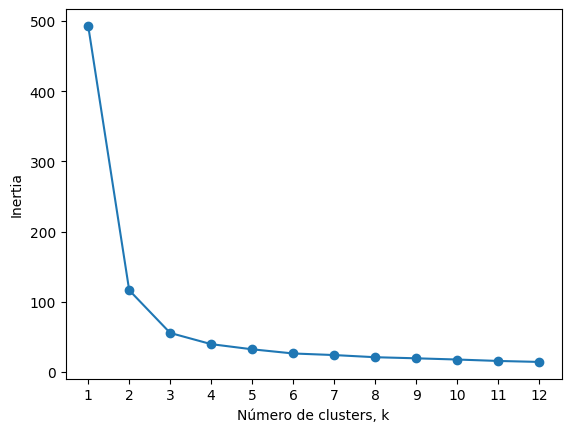

In [ ]:
plt.plot(list(inertias.keys()),
         list(inertias.values()), '-o')
plt.xlabel('Número de clusters, k')
plt.ylabel('Inertia')
plt.xticks(list(inertias.keys()))
plt.show()

A medida que aumentamos k, la inercia cae muy rápid. Esta curva tiene aproximadamente la forma de un brazo, y hay un "codo" en k = 3.

__SI NO TUVIERAMOS MAS CONOCIMIENTO DE LOS DATOS k = 3 SERíA UNA BUENA OPCIÓN__

* Cualquier valor antes del codo sería dramático
* Cualquier valor despues del codo no ayudaría mucho, ya que podríamos simplemente estar dividiendo grupos perfectamente buenos por la mitad sin una buena razón.

Entonces, __si no hay información que ayude a tomar una mejor decisión, el valor del codo es la mejor opción__.

__NOTA__: En general este proceso no es sencillo y hay que tener en cuenta que K-Means es muy sensible a diferencias en las varianzas de las variables y a variables con escalas muy distintas.

#### Silhouette

* Un enfoque más preciso (pero también computacionalmente más costoso) es utilizar el __Silhouette score__.

* El __Silhouette score__ es el silhouette medio sobre todas las instancias.

* El Silhouette de una instancia se define cómo $\frac{b-a}{max(a, b)}$ dónde:
    * $a$ es la distancia media a otras instancias en el mismo cluster (la distancia intra cluster media)
    * $b$ es la media de la distancia al cluster mas cercano (la distancia media a las instancias del siguiente cluster, definida como la que minimiza a $b$, excluyendo la distancia del propio cluster)

* El coeficiente Silouette está entre -1 y 1 esto se interpreta:
    * Entre mas cerca está de 1, significa que la instancia está bien dentro de su cluster y lejos de otros clusters
    * Entre mas cerca está de 0, significa que está muy cerca de una frontera entre clusters
    * Entre mas cerca está de -1 significa que la instancia ha sido asignada a un cluster donde no corresponde

##### Silhouette scores

In [ ]:
from sklearn.metrics import silhouette_score

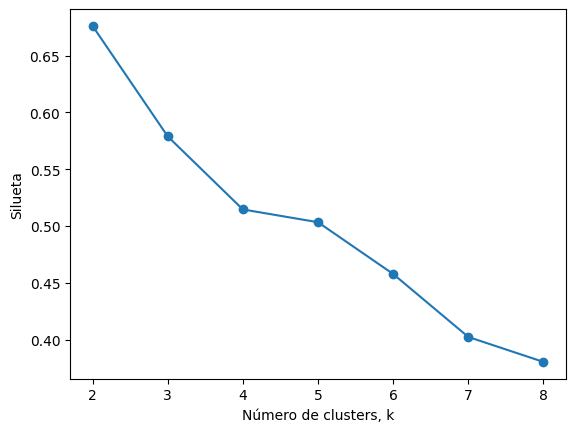

In [ ]:
silhouettes = {k: silhouette_score(X_train, KMeans(n_clusters=k).fit_predict(X_train)) for k in range(2, 9)}

plt.plot(list(silhouettes.keys()),
         list(silhouettes.values()), '-o')
plt.xlabel('Número de clusters, k')
plt.ylabel('Silueta')
plt.xticks(list(silhouettes.keys()))
plt.show()

Está visualización es mas informativa que la gráfica del codo, en esta visualización observamos que `k=2` es un excelente `k`, pero `k=3` también es una excelente opción, estas opciones son mucho mejores que el resto, esta gráfica puede llegar a ser mas informativa que solo comparar inercias.

##### Silhouette diagrama

Una visualización aun mas informativa se obtiene cuando gráficamos el silhouette de cada instancia, agrupada por los clusters que los contiene y ordenada por sus valores.

Cada diagrama tiene forma de cuchillo por cluster:
* La altura del cuchillo significa la cantidad de instancias que contiene el cluster
* El ancho representa los coeficientes silhouette ordenados en el cluster (entre mas ancho mejor)
* La linea punteada representa el coeficiente silhouette medio

For n_clusters = 2, the average silhouette_score is: 0.6761
For n_clusters = 3, the average silhouette_score is: 0.5758
For n_clusters = 4, the average silhouette_score is: 0.5146
For n_clusters = 5, the average silhouette_score is: 0.4089
For n_clusters = 6, the average silhouette_score is: 0.3977
For n_clusters = 7, the average silhouette_score is: 0.3980
For n_clusters = 8, the average silhouette_score is: 0.3463


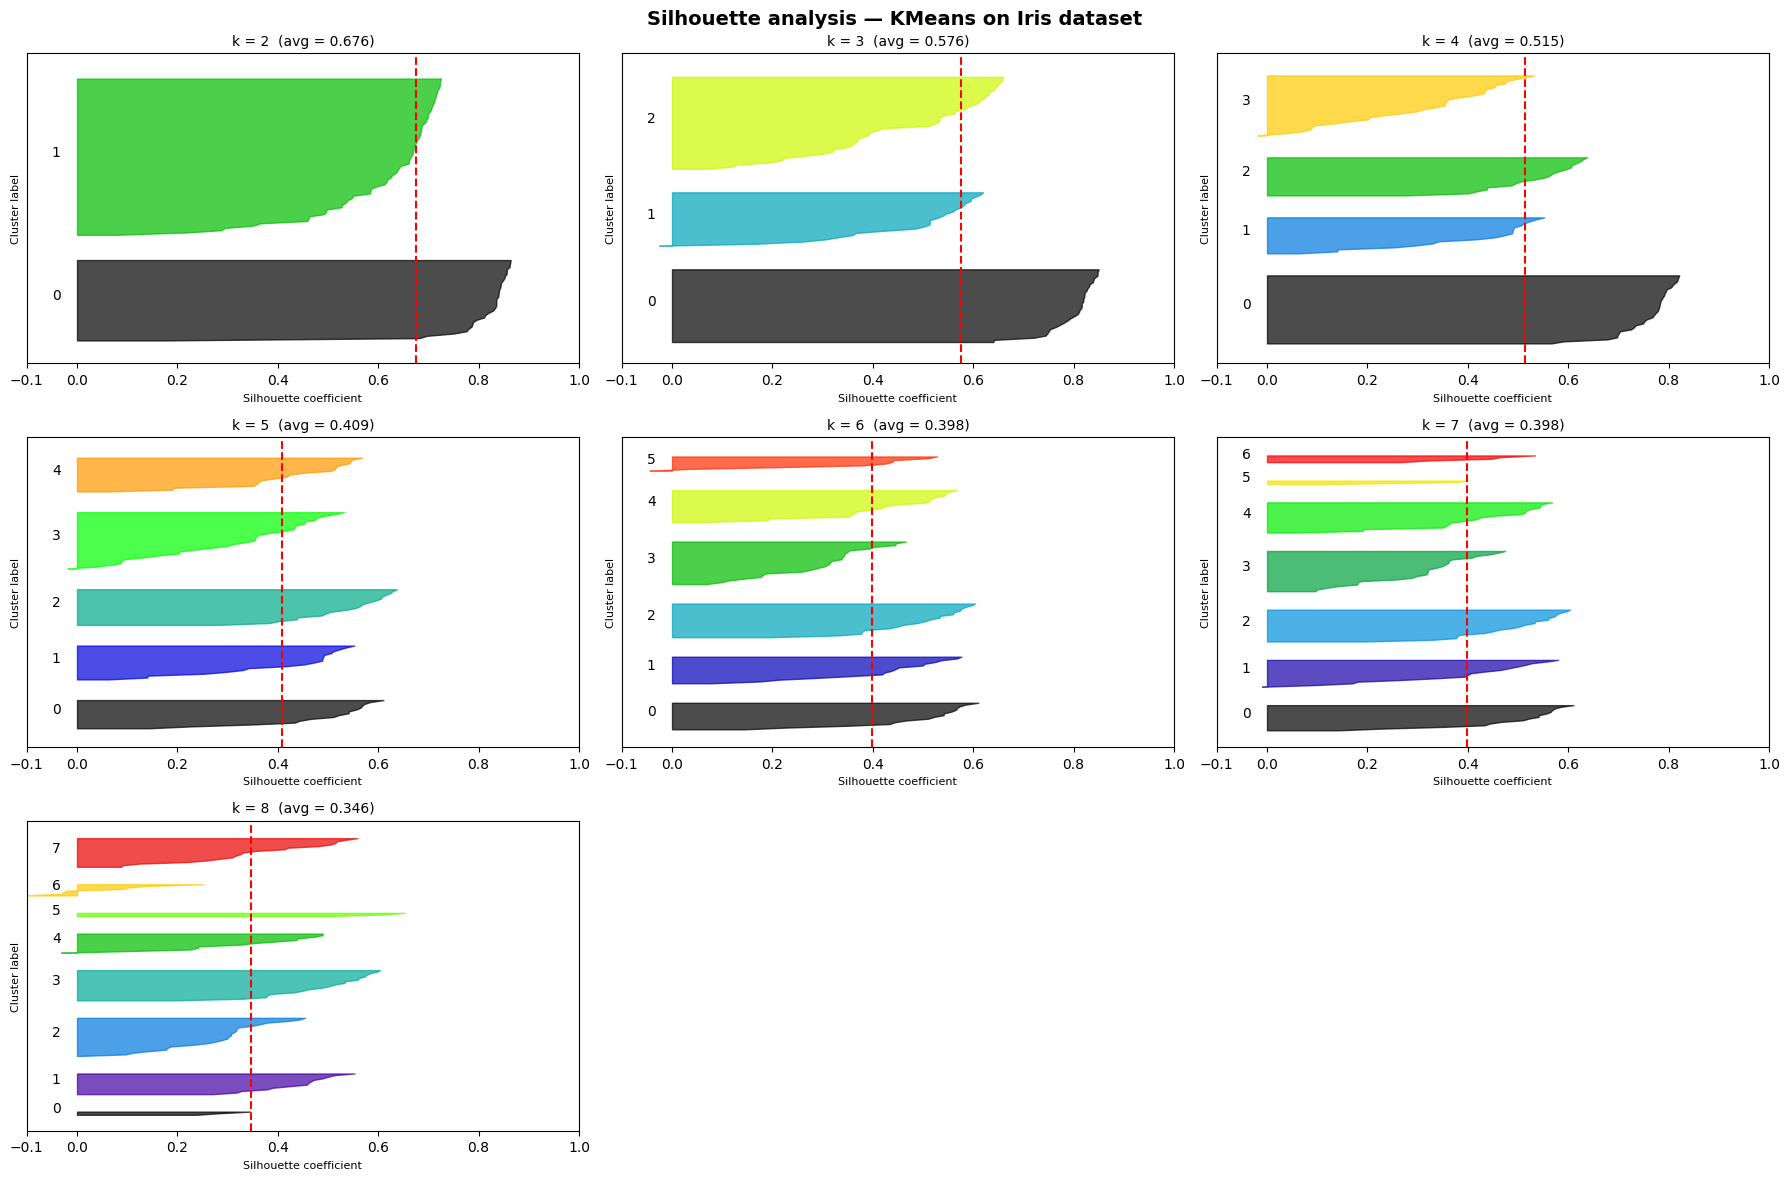

In [ ]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

n_clusters_range = range(2, 9)
n_plots = len(n_clusters_range)
cols = 3
rows = (n_plots + cols - 1) // cols  # ceil division

fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))
axes = axes.flatten()

for idx, k in enumerate(n_clusters_range):
    ax = axes[idx]

    ax.set_xlim([-0.1, 1])
    ax.set_ylim([0, len(X_train) + (k + 1) * 10])

    clusterer = KMeans(n_clusters=k, random_state=10, n_init='auto')
    cluster_labels = clusterer.fit_predict(X_train)

    silhouette_avg = silhouette_score(X_train, cluster_labels)
    print(f"For n_clusters = {k}, the average silhouette_score is: {silhouette_avg:.4f}")

    sample_silhouette_values = silhouette_samples(X_train, cluster_labels)

    y_lower = 10
    for i in range(k):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax.set_title(f"k = {k}  (avg = {silhouette_avg:.3f})", fontsize=10)
    ax.set_xlabel("Silhouette coefficient", fontsize=8)
    ax.set_ylabel("Cluster label", fontsize=8)
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_yticks([])
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

# Ocultar subplots sobrantes (si el total no es múltiplo de cols)
for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Silhouette analysis — KMeans on Iris dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

#### Recomendaciones para K-means

* Normalizar las variables antes de hacer K-means, restar a cada variable su media y dividirla por la desviación típica

## Challenge

Considera los datos `creditcard.csv`. Los puedes encontrar [aquí](https://drive.google.com/file/d/1jqZ6--OOGk477xv_yxqyell8RBtlOXL8/view?usp=drive_link)

Como contexto, estos datos fueron obtenidos del siguiente enlace: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

Consejo: Lee atentamente la descripción del dataset y el significado de las columnas en el enlace anterior.


### Realiza lo siguiente
1. Entrena un modelo con KMeans, recuerda separar la columna objetivo `Class` del resto de las columnas.
2. Identifica la mejor K utilizando el método del codo y el método de las siluetas.
3. Añade una columna llamada `cluster` etiquetando el set de prueba (30% de los datos).
4. Identifica el grupo al que pertenecen los datos cuyo `Class` es igual a 1. ¿Pertenecen a un solo grupo o a varios?

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "creditcard.csv"

# Load the latest version
df_credit = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mlg-ulb/creditcardfraud",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df_credit.head())

/tmp/ipykernel_13494/4123245572.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df_credit = kagglehub.load_dataset(


Using Colab cache for faster access to the 'creditcardfraud' dataset.
First 5 records:    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ...

In [ ]:
df_credit.shape

(284807, 31)

In [ ]:
df_credit.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
df_credit.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [ ]:
df_credit.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [ ]:
df_credit.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df_credit.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [ ]:
# Realizamos un count de valores de clase, 0 corresponde a no fraude,
# 1 corresponde a fraude
print('No es fraude el', round(df_credit['Class'].value_counts()[0]/len(df_credit) * 100,2), '% del dataset')
print('es fradude', round(df_credit['Class'].value_counts()[1]/len(df_credit) * 100,2), '% del dataset')

No es fraude el 99.83 % del dataset
es fradude 0.17 % del dataset


Se identifica que el dataset presenta un desbalance extremo entre las clases, donde el 99.83% de las transacciones corresponden a operaciones legítimas y únicamente el 0.17% a transacciones fraudulentas. Esta disparidad podría afectar el desempeño del modelo de clustering, ya que los casos de fraude representan una proporción muy pequeña de los datos y podrían no formar grupos claramente diferenciados.

Por otra parte, el conjunto de datos cuenta con 284,806 registros, lo que proporciona una cantidad considerable de información para el entrenamiento del modelo y permite identificar patrones de comportamiento con mayor estabilidad estadística.

Es importante considerar que K-Means es un algoritmo de aprendizaje no supervisado que busca agrupar observaciones similares sin utilizar la variable objetivo. Debido al fuerte desbalance presente en el dataset, no se espera necesariamente que las transacciones fraudulentas formen un cluster exclusivo; por ello, será necesario analizar posteriormente la distribución de los casos de fraude dentro de los clusters generados.


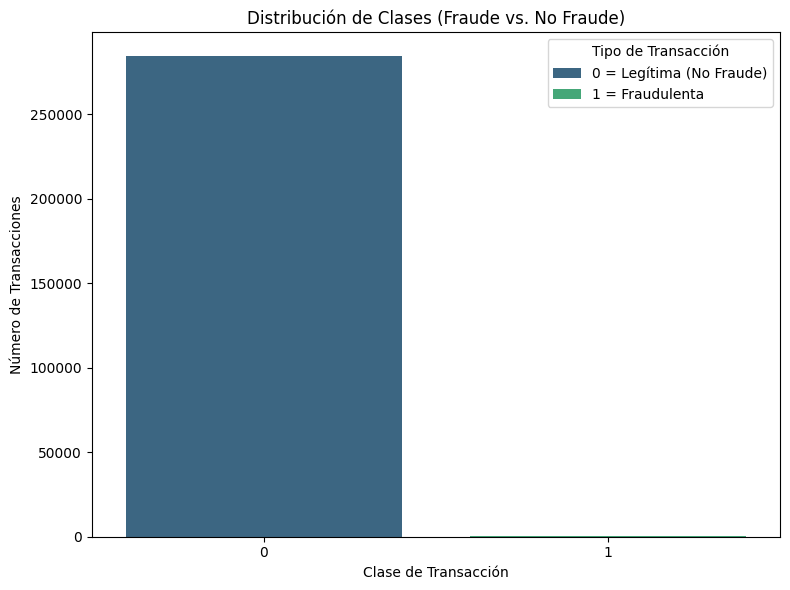

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
ax = sns.countplot(x='Class', data=df_credit, hue='Class', palette='viridis', legend=True)

plt.title('Distribución de Clases (Fraude vs. No Fraude)')
plt.xlabel('Clase de Transacción')
plt.ylabel('Número de Transacciones')

legend = ax.get_legend()

# Update the legend labels to reflect the true meaning of the data
# (0 = Non-Fraudulent/Legitimate, 1 = Fraudulent)
if legend:
    # Assuming the order of legend entries corresponds to sorted unique 'Class' values (0 then 1)
    legend.texts[0].set_text('0 = Legítima (No Fraude)')
    legend.texts[1].set_text('1 = Fraudulenta')
    legend.set_title('Tipo de Transacción')

plt.tight_layout()
plt.show()

En la grafica vemos de forma visual la gran disparidad que hay entre clases.

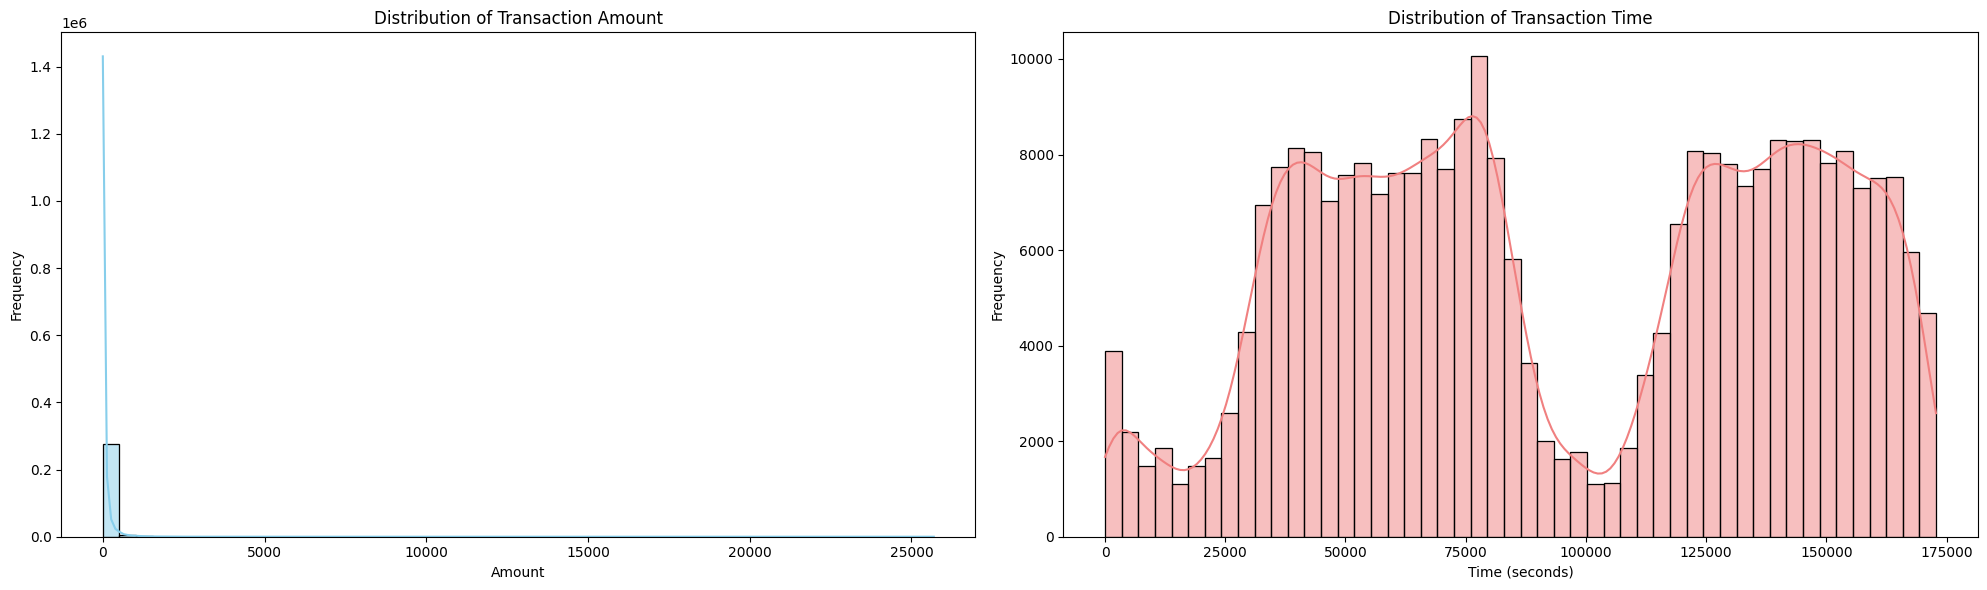

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Plot distribution for 'Amount' with KDE
sns.histplot(df_credit['Amount'], bins=50, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of Transaction Amount')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')

# Plot distribution for 'Time' with KDE
sns.histplot(df_credit['Time'], bins=50, kde=True, color='lightcoral', ax=axes[1])
axes[1].set_title('Distribution of Transaction Time')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
X = df_credit.drop('Class', axis = 1 )
y = df_credit['Class']



In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.30,
    random_state = 42,
    stratify = y

)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled[:5]

array([[ 1.25799168e+00, -5.57826383e-03,  4.27819302e-01,
         1.08346890e-01, -5.34196278e-01,  4.25863683e-01,
        -4.89116243e-01,  6.76802298e-01, -3.17973776e-04,
        -1.69657901e-01, -2.04596939e-01,  3.71250945e-01,
         3.84924806e-01, -6.52690971e-01,  4.36586368e-01,
        -1.10396938e+00,  2.60220428e-01, -8.72575294e-01,
        -8.08109117e-02,  4.04491892e-01, -4.80497380e-02,
        -3.13204003e-01, -7.88791216e-01,  6.70733037e-02,
        -5.96328746e-01, -9.47612636e-01,  2.95700262e-01,
         5.79622746e-01,  2.52461592e-01, -3.21082095e-01],
       [ 9.39712889e-01,  9.04109150e-01, -1.10138288e-01,
        -1.44936147e+00,  8.40920356e-01,  4.42775857e-01,
        -7.60781903e-01,  7.36596284e-01, -3.22161901e-01,
        -2.91514578e-01,  4.73741681e-01,  4.81193941e-01,
         2.46875182e-01, -1.06035604e+00,  1.29602063e+00,
        -4.74665365e-01, -1.53534910e-01, -8.51351530e-01,
         3.91442528e-01, -2.03885826e-02, -3.78882627e-

In [ ]:
X_train_scaled.mean()

np.float64(-1.2729589116171883e-18)

In [ ]:
X_train_scaled.std()

np.float64(1.0000000000000002)

Se verificó el resultado del escalamiento calculando la media y la desviación estándar del conjunto de entrenamiento transformado. La media obtenida fue cercana a 0 y la desviación estándar cercana a 1, lo que confirma que la estandarización se realizó correctamente.

Este paso es fundamental para K-Means, ya que el algoritmo utiliza distancias euclidianas para formar los clusters. Al estandarizar las variables se evita que aquellas con rangos de valores más grandes tengan una influencia desproporcionada en el proceso de agrupamiento.


## Metodo del codo (Elbow method)

In [ ]:
from sklearn.cluster import KMeans

inertias = []
k_values = range(2,11)

for k in k_values:
  kmeans = KMeans(
      n_clusters = k,
      random_state = 42,
      n_init = 10
  )

  kmeans.fit(X_train_scaled)

  inertias.append(kmeans.inertia_)


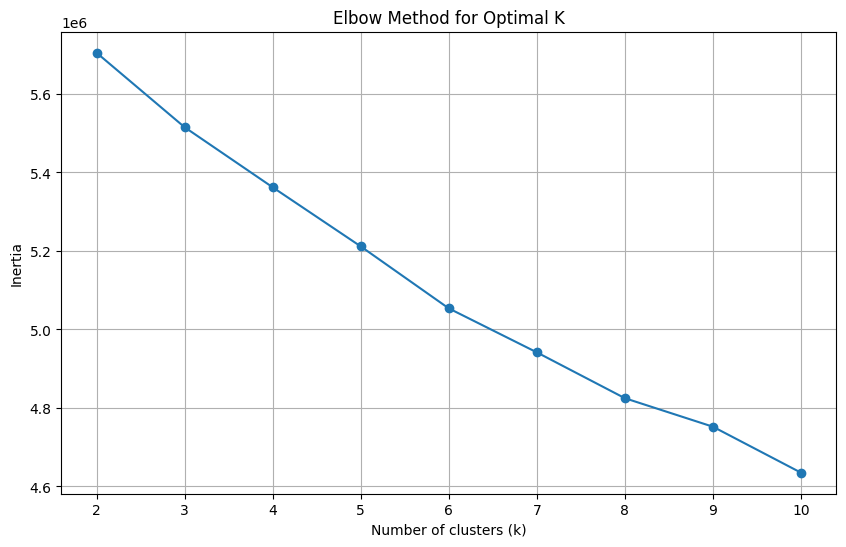

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(k_values, inertias, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_values)
plt.grid(True)
plt.show()

En el método del codo se observa una disminución progresiva de la inercia conforme aumenta el número de clusters. Aunque la curva no presenta un punto de inflexión completamente marcado, se identifica que alrededor de K=8 la reducción de la inercia comienza a ser menos pronunciada. Por esta razón, K=8 se considera un candidato inicial para el número óptimo de clusters.

Sin embargo, debido a que la gráfica mantiene una tendencia descendente gradual, el método del codo por sí solo no es suficiente para tomar una decisión definitiva. Por ello, se complementa el análisis con el método de siluetas, que permite evaluar la calidad de separación entre los clusters.

In [ ]:
import numpy as np
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Convertimos y_train a array para filtrar
y_train_array = np.array(y_train)

# Índices de fraude y no fraude dentro del train
fraud_indices = np.where(y_train_array == 1)[0]
normal_indices = np.where(y_train_array == 0)[0]

# Tomamos todos los fraudes disponibles
selected_fraud_indices = fraud_indices

# Tomamos una muestra de transacciones normales
np.random.seed(42)
selected_normal_indices = np.random.choice(
    normal_indices,
    size=10000,
    replace=False
)

# Combinamos índices
sample_indices = np.concatenate([
    selected_fraud_indices,
    selected_normal_indices
])

# Creamos muestra escalada
X_sample_scaled = X_train_scaled[sample_indices]

K=2, Silhouette Score=0.0580646169024604
K=3, Silhouette Score=0.05856740713860721
K=4, Silhouette Score=0.019370437908379372
K=5, Silhouette Score=0.027544837008160565
K=6, Silhouette Score=0.05567877170323376
K=7, Silhouette Score=0.05240664985321164
K=8, Silhouette Score=0.0874767650035772
K=9, Silhouette Score=0.052144813012306085
K=10, Silhouette Score=0.0584978490766108


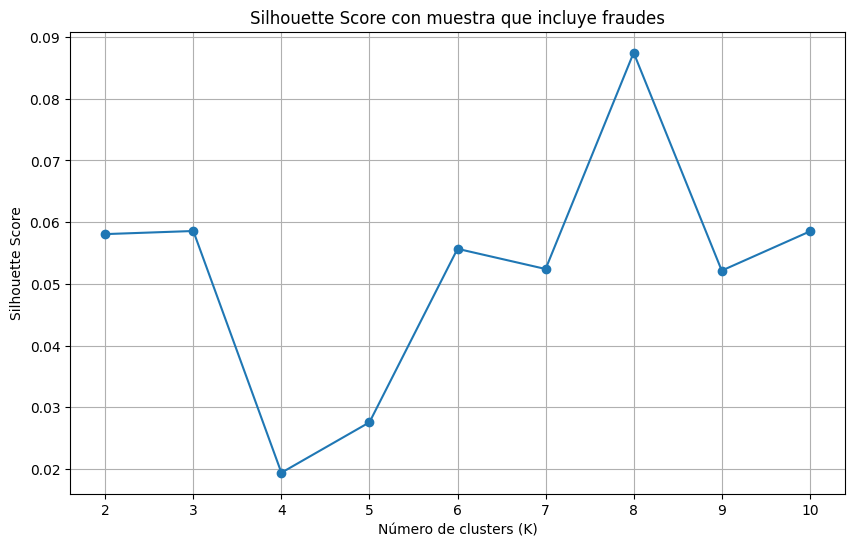

In [ ]:
silhouettes = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_train_scaled)

    sample_labels = kmeans.predict(X_sample_scaled)

    silhouette_avg = silhouette_score(
        X_sample_scaled,
        sample_labels
    )

    silhouettes.append(silhouette_avg)
    print(f"K={k}, Silhouette Score={silhouette_avg}")

plt.figure(figsize=(10, 6))
plt.plot(k_values, silhouettes, marker='o')
plt.title("Silhouette Score con muestra que incluye fraudes")
plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.grid(True)
plt.show()

El método del codo mostró una disminución progresiva de la inercia sin presentar un punto de inflexión completamente definido. No obstante, alrededor de K=8 la reducción de la inercia comenzó a ser menos pronunciada, por lo que se consideró como un posible candidato.

Posteriormente, se aplicó el método de siluetas para evaluar la calidad de separación entre los clusters. El valor máximo del Silhouette Score se obtuvo con K=8, alcanzando aproximadamente 0.088, superando al resto de las configuraciones evaluadas.

Dado que tanto el método del codo como el método de siluetas señalan a K=8 como la mejor alternativa, se seleccionó este valor para entrenar el modelo final de K-Means. Aunque los valores de silueta obtenidos son relativamente bajos, esto es consistente con la naturaleza del dataset, que presenta un fuerte desbalance entre clases y patrones complejos de comportamiento transaccional.


In [ ]:
best_k = 8

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_final.fit(X_train_scaled)

KMeans(n_init=10, random_state=42)

In [ ]:
test_clusters = kmeans_final.predict(X_test_scaled)
test_results = X_test.copy()
test_results["Class"] = y_test.values
test_results['cluster'] = test_clusters

test_results.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,cluster
186882,127294.0,-2.537331,1.890864,-0.840555,-1.102759,-2.105725,0.367811,-2.737844,-3.543314,-0.483147,...,-2.167329,1.022567,-0.241143,-1.094885,-0.475427,-0.177157,-0.082691,37.40,0,5
165754,117632.0,-0.250839,1.104108,0.206089,0.417324,1.204079,-0.350694,1.369769,-0.133535,-0.957100,...,0.499501,-0.392572,-0.393364,0.233354,-0.490717,0.143897,0.136810,9.27,0,2
235285,148330.0,0.568980,-2.520416,-1.114138,1.670652,-1.128945,0.398822,0.190403,0.161493,0.840595,...,-0.760732,-0.181332,0.595866,-0.760920,-1.048927,-0.096970,0.088686,700.00,0,1
101271,67778.0,1.328892,0.226908,-0.308968,0.381772,0.238490,-0.282946,0.029460,-0.079962,0.227173,...,-1.148959,-0.047403,-1.074464,0.375683,0.182045,-0.031732,0.017501,14.99,0,0
5832,6308.0,1.124863,-0.165691,1.337053,1.030033,-0.891116,0.202926,-0.825094,0.163280,2.301808,...,-0.195607,0.072785,0.045625,0.135192,0.308617,0.001142,0.017673,17.25,0,0


In [ ]:
fraud_by_cluster = test_results[test_results['Class'] == 1]['cluster'].value_counts()
fraud_by_cluster

,count
cluster,
6,75
0,30
1,29
2,10
3,2
5,2


In [ ]:
import pandas as pd

pd.crosstab(test_results['cluster'], test_results['Class'])

Class,0,1
cluster,,
0,34690,30
1,15720,29
2,17076,10
3,1151,2
4,5111,0
5,10561,2
6,15,75
7,971,0


In [ ]:
pd.crosstab(
    test_results['cluster'],
    test_results['Class'],
    normalize = 'index'
)*100

Class,0,1
cluster,,
0,99.913594,0.086406
1,99.815861,0.184139
2,99.941473,0.058527
3,99.826539,0.173461
4,100.000000,0.000000
5,99.981066,0.018934
6,16.666667,83.333333
7,100.000000,0.000000


**Conclusión**:
Al revisar los conteos reales por cluster, se observa que el cluster 6 contiene 90 registros en total, de los cuales 75 corresponden a transacciones fraudulentas y 15 a transacciones legítimas. Esto significa que el 83.33% de los registros dentro de este cluster son fraudes.

Además, de los 148 fraudes presentes en el conjunto de prueba, 75 fueron asignados al cluster 6, lo que representa aproximadamente el 50.67% del total de transacciones fraudulentas del conjunto de prueba.

Este resultado es relevante porque, aunque K-Means no utilizó la columna Class durante el entrenamiento, logró formar un cluster pequeño pero altamente asociado con transacciones fraudulentas. Sin embargo, el resto de los fraudes se distribuye entre otros clusters, principalmente los clusters 0, 1 y 2, por lo que el modelo no separa todos los casos fraudulentos en un único grupo.